# Predictive Maintenance – Hybrid AI System


#### **Importation Des Librairies /Importing Libraries**

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve


#### **1. Chargement et Nettoyage / Data Loading and Cleaning**

In [69]:
df=pd.read_csv("../Data/ai4i2020.csv")
df = df.drop(columns=["UDI","Product ID"])
df.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


#### **2. Exploratory Data Analysis (EDA)**

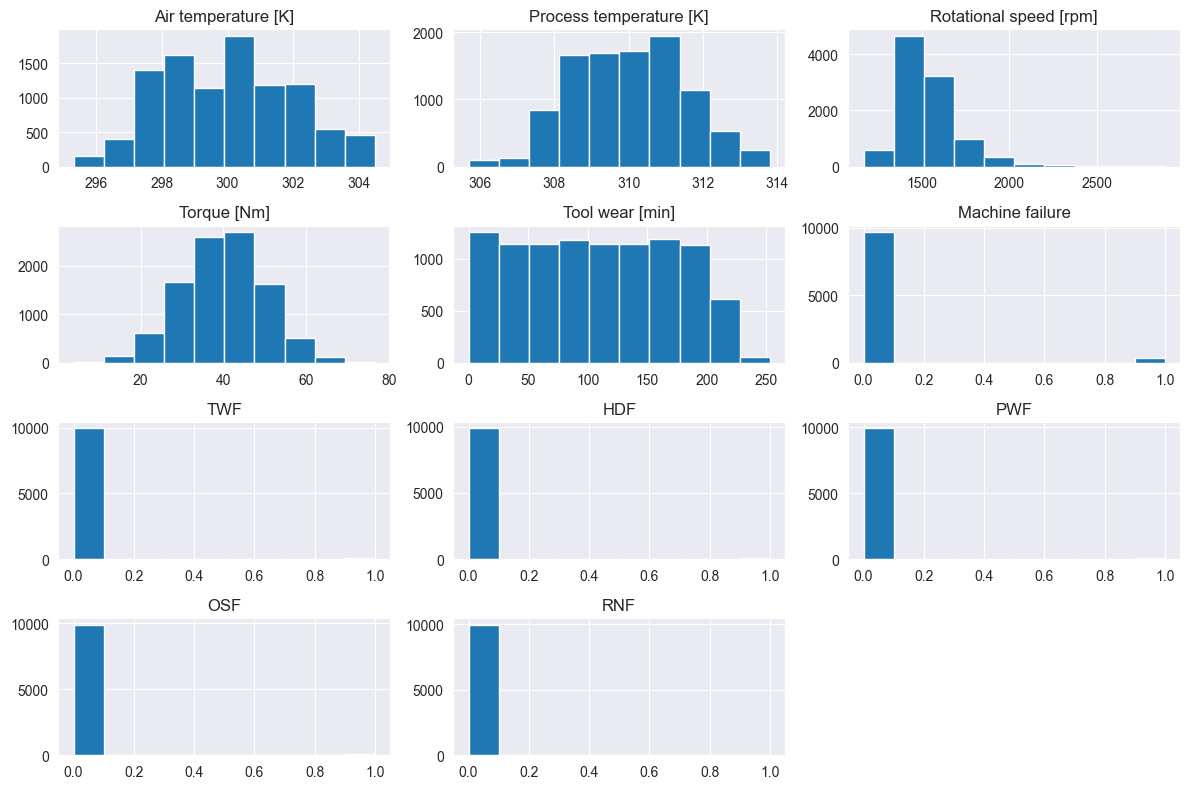

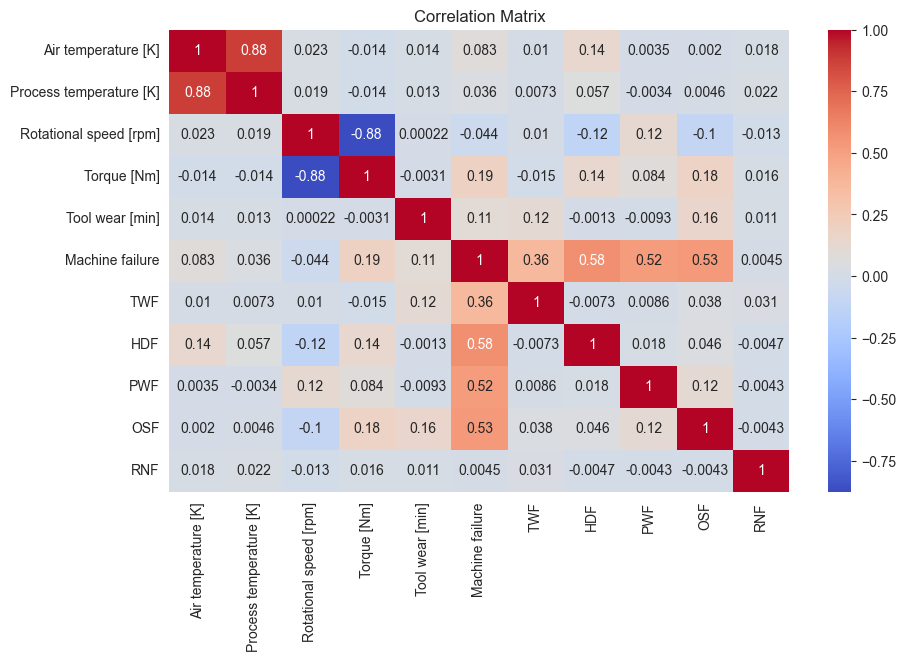

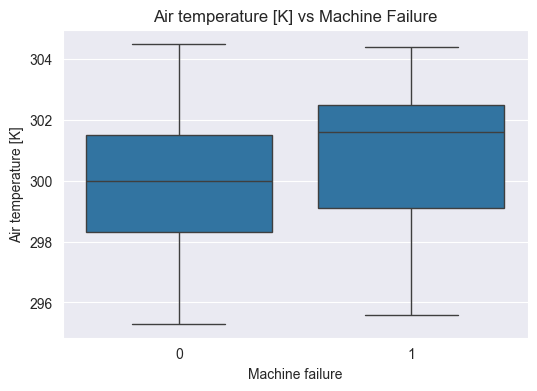

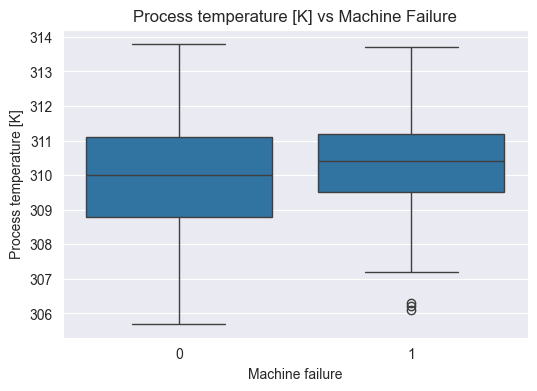

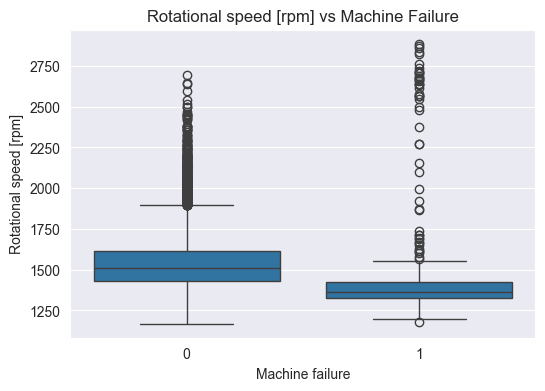

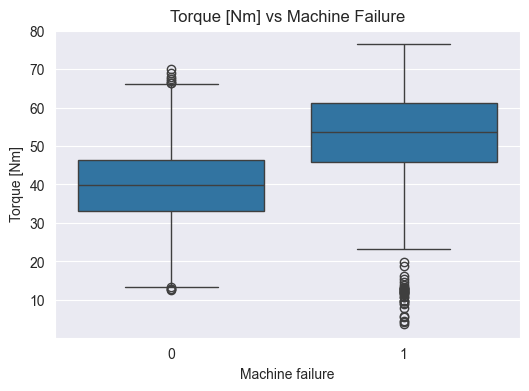

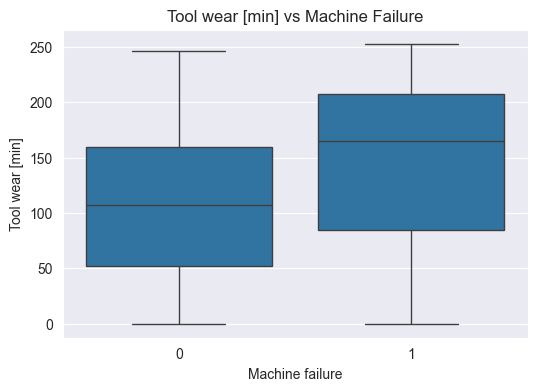

In [70]:
# Visualisation de la distribution
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Matrice de corrélation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Boxplots pour visualiser les anomalies par rapport à la panne
features_to_plot = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for f in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Machine failure", y=f, data=df)
    plt.title(f"{f} vs Machine Failure")
    plt.show()


#### **3. Feature Engineering**

In [71]:
# Calculs de variables physiques (depuis final_hybrid_project)
df["Temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Power_approx"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]
df["Wear_ratio"] = df["Tool wear [min]"] / df["Tool wear [min]"].max()

# Alertes basées sur les outliers (depuis analyse)
q1_t, q3_t = df["Torque [Nm]"].quantile([0.25, 0.75])
iqr_t = q3_t - q1_t
upper_t = q3_t + 1.5 * iqr_t
lower_t = q1_t - 1.5 * iqr_t

q1_s, q3_s = df["Rotational speed [rpm]"].quantile([0.25, 0.75])
iqr_s = q3_s - q1_s
upper_s = q3_s + 1.5 * iqr_s

df["Torque_Alert"] = ((df["Torque [Nm]"] > upper_t) | (df["Torque [Nm]"] < lower_t)).astype(int)
df["Speed_Alert"] = (df["Rotational speed [rpm]"] > upper_s).astype(int)

df.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temp_diff,Power_approx,Wear_ratio,Torque_Alert,Speed_Alert
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.011858,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.019763,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.027668,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.035573,0,0


#### **4. Préparation des données / Data Preparation**

In [72]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scaler global pour l'inférence sur tout le dataset
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X)


#### **5. Modèle Machine Learning (Random Forest)**

In [73]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob)}")


Accuracy: 0.999
ROC AUC: 0.9810109994166336


#### **6. Détection d'Anomalies (Isolation Forest)**

In [74]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df["anomaly_score"] = iso_forest.fit_predict(X_full_scaled)
df["anomaly_flag"] = df["anomaly_score"].apply(lambda x: 1 if x == -1 else 0)

print("Répartition des anomalies détectées :")
print(df["anomaly_flag"].value_counts())


Répartition des anomalies détectées :
anomaly_flag
0    9500
1     500
Name: count, dtype: int64


#### **7. Système Expert / Expert System**

In [75]:
def expert_system(row):
    # Règles basées sur la connaissance métier
    if row["Torque [Nm]"] > 60 and row["Tool wear [min]"] > 200:
        return 1
    elif row["Torque [Nm]"] > 50 and row["Process temperature [K]"] > 310:
        return 1
    elif row["Tool wear [min]"] > 180:
        return 1
    else:
        return 0

df["expert_prediction"] = df.apply(expert_system, axis=1)


#### **8. Système Hybride / Hybrid System Decision**

In [76]:
# On récupère les prédictions RF sur tout le dataset pour la décision hybride
df["ml_prediction"] = rf_model.predict(scaler_full.transform(X))

def hybrid_decision(row):
    # Score combinant ML, Système Expert et Détection d'Anomalies
    score = row["ml_prediction"] + row["expert_prediction"] + row["anomaly_flag"]
    if score >= 2:
        return "High Risk"
    elif score == 1:
        return "Medium Risk"
    else:
        return "Low Risk"

df["hybrid_risk"] = df.apply(hybrid_decision, axis=1)


#### **9. Résultats Finaux / Final Results**

In [77]:
print("Distribution des décisions hybrides :")
print(df["hybrid_risk"].value_counts())

print("\nComparaison avec les pannes réelles :")
print(pd.crosstab(df["Machine failure"], df["hybrid_risk"]))

Distribution des décisions hybrides :
hybrid_risk
Low Risk       7373
Medium Risk    2261
High Risk       366
Name: count, dtype: int64

Comparaison avec les pannes réelles :
hybrid_risk      High Risk  Low Risk  Medium Risk
Machine failure                                  
0                       58      7366         2237
1                      308         7           24
